# DarkNav - Synthetic Dataset Generation and Preprocessing Pipeline

**Author:** Miriam Garcia Sollo  
**Date:** June 2026

## Objectives

1. Inspect real HDF5 structure to understand the DeepMoon format
2. Verify the production synthetic generator (src/synthetic.py)
3. Run parameter ablation: with vs without ellipticity, with vs without ejecta rim
4. Generate the full 1500-sample synthetic dataset and save to disk
5. Run the real DEM preprocessing pipeline (src/preprocessing.py)
6. Verify both datasets and check DataLoader output shapes
7. Compute class balance and pos_weight for training

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.synthetic import (
    make_single_crater,
    make_multi_crater_patch,
    generate_synthetic_dataset,
    SyntheticCraterDataset,
    RealCraterDataset,
    CombinedDataset,
)
from src.preprocessing import process_split

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 10

DATA_DIR = Path('../data')
DOCS_DIR = Path('../docs')
PROC_DIR = DATA_DIR / 'processed'
SYNTH_DIR = DATA_DIR / 'synthetic'

PROC_DIR.mkdir(parents=True, exist_ok=True)
SYNTH_DIR.mkdir(parents=True, exist_ok=True)

print('Imports OK')
print('Files in data/:', sorted([f.name for f in DATA_DIR.iterdir()]))

Imports OK
Files in data/: ['.gitkeep', 'LunarLROLrocKaguya_118mperpix.png', 'dev_craters.hdf5', 'dev_images.hdf5', 'model_keras1.2.2.h5', 'model_keras2.h5', 'post-processed_sample_images.zip', 'post-processed_test_craters.npy', 'processed', 'synthetic', 'test_craters.hdf5', 'test_images.hdf5', 'train_craters.hdf5', 'train_images.hdf5', 'train_valid_indices.npy']


## 1. Inspect the real HDF5 structure

The DeepMoon HDF5 files use Groups (not Datasets) at the top level.
Each Group contains subkeys '0', '1', ..., 'N-1', one per patch.
The masks are already precomputed in 'target_masks' — no CSV needed.

In [2]:
import h5py

hdf5_path = DATA_DIR / 'train_images.hdf5'

if hdf5_path.exists():
    with h5py.File(hdf5_path, 'r') as f:
        print('Top-level keys:', list(f.keys()))
        print()
        for k in f.keys():
            item = f[k]
            if hasattr(item, 'shape'):
                print(f"  Dataset '{k}': shape={item.shape}, dtype={item.dtype}")
            else:
                # Group with numbered subkeys
                subkeys = list(item.keys())
                first   = item[subkeys[0]]
                print(f"  Group   '{k}': {len(subkeys)} items, "
                      f"first shape={first.shape}, dtype={first.dtype}")
else:
    print('HDF5 not found at', hdf5_path)
    print('Download: cd ../data && zenodo_get 1133969')

Top-level keys: ['cll_xy', 'input_images', 'longlat_bounds', 'pix_bounds', 'pix_distortion_coefficient', 'target_masks']

  Group   'cll_xy': 30000 items, first shape=(2,), dtype=float64
  Dataset 'input_images': shape=(30000, 256, 256), dtype=uint8
  Group   'longlat_bounds': 30000 items, first shape=(4,), dtype=float64
  Group   'pix_bounds': 30000 items, first shape=(4,), dtype=int32
  Group   'pix_distortion_coefficient': 30000 items, first shape=(1,), dtype=float64
  Dataset 'target_masks': shape=(30000, 256, 256), dtype=float32


## 2. Verify the production synthetic generator

In [3]:
dem, mask = make_single_crater(size=128, r_s=20, noise_std=0.03,
                               rng=np.random.default_rng(0))

print('Single crater sanity checks:')
print(f'  DEM shape  : {dem.shape}  dtype={dem.dtype}')
print(f'  Mask shape : {mask.shape} dtype={mask.dtype}')
print(f'  DEM range  : [{dem.min():.3f}, {dem.max():.3f}]')
print(f'  DEM centre : {dem[64,64]:.3f}  (should be near -1.0, the bowl)')
print(f'  Mask pixels: {mask.sum()} out of {mask.size}')

assert dem.dtype  == np.float32, 'DEM must be float32'
assert mask.dtype == np.uint8,   'Mask must be uint8'
assert dem[64,64] < -0.5,        'Centre must be inside the bowl'
assert mask.sum() > 0,           'Mask must be non-empty'
print('All assertions passed.')

Single crater sanity checks:
  DEM shape  : (128, 128)  dtype=float32
  Mask shape : (128, 128) dtype=uint8
  DEM range  : [-0.967, 0.309]
  DEM centre : -0.967  (should be near -1.0, the bowl)
  Mask pixels: 24 out of 16384
All assertions passed.


## 3. Generator ablation: contribution of each component

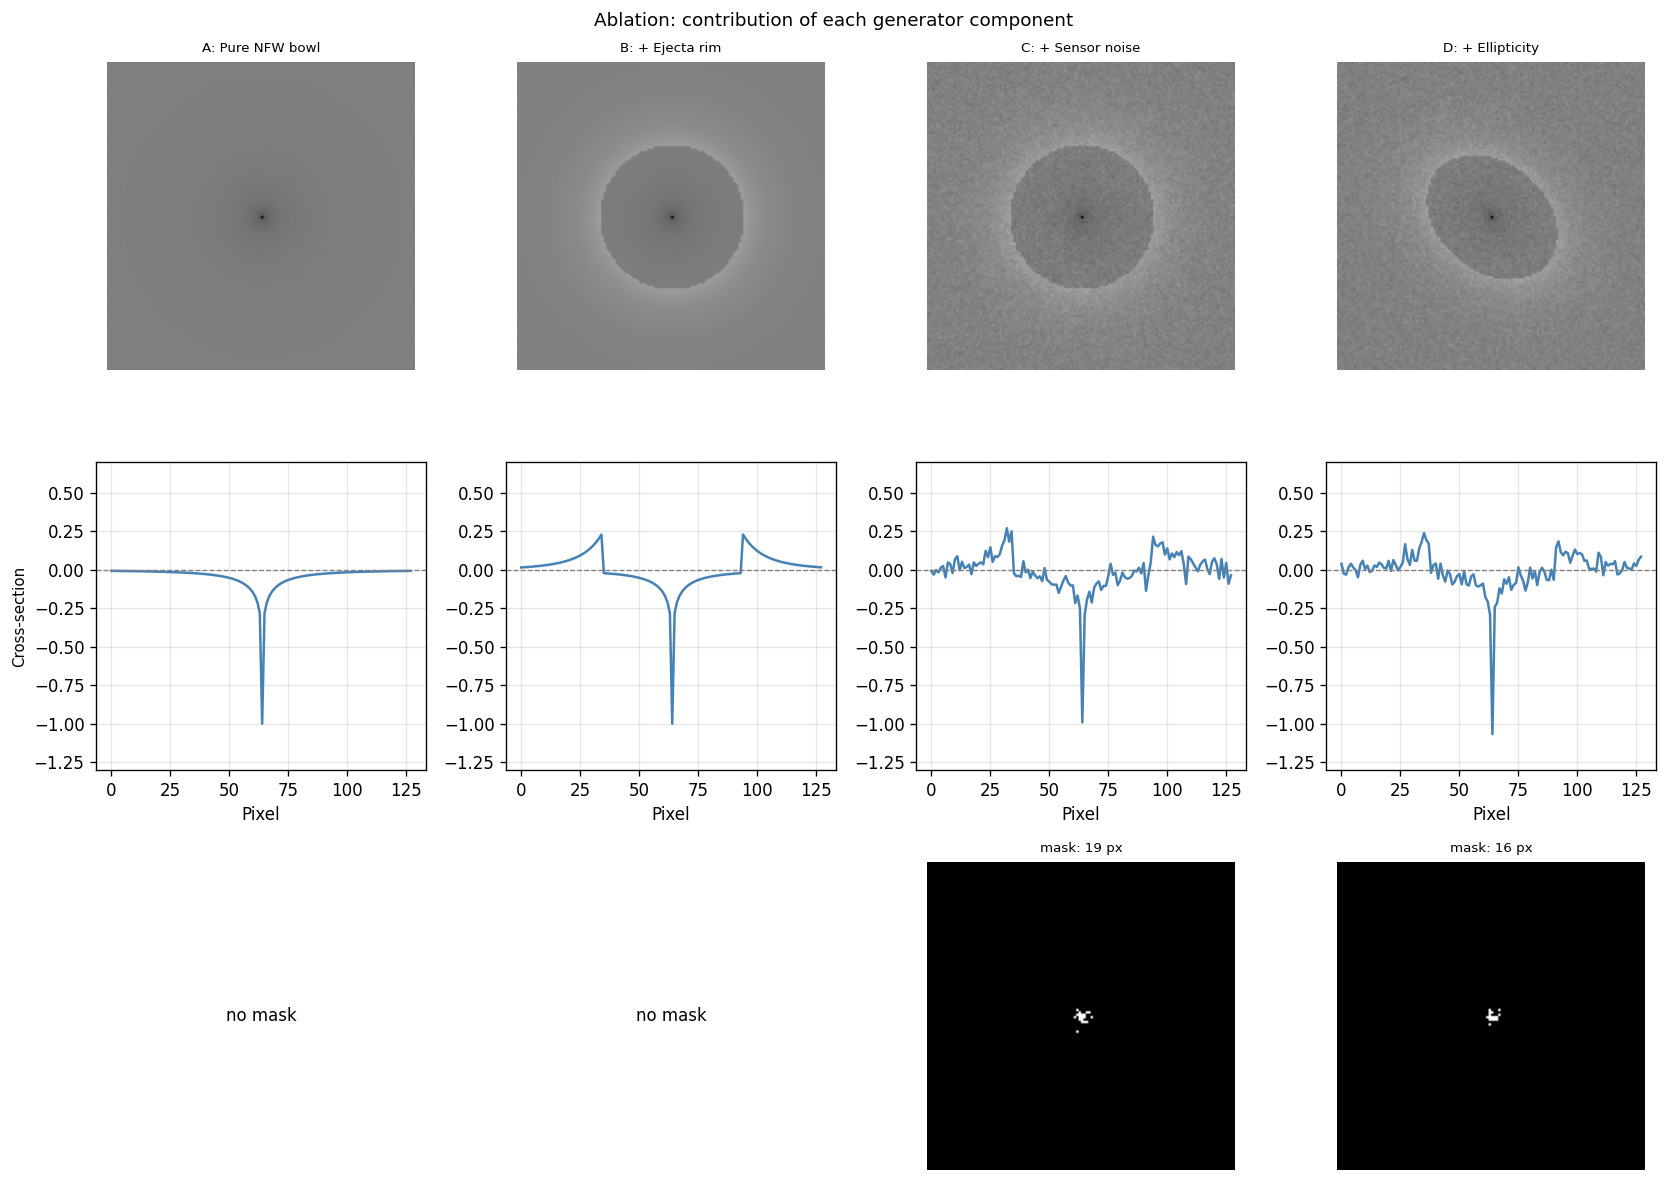

Saved: fig13_generator_ablation.png


In [4]:
from src.synthetic import nfw_projected_sigma

# Variant A: pure NFW inversion, no rim, no noise
def pure_nfw(size=128, r_s=20):
    cx, cy = size//2, size//2
    yg, xg = np.ogrid[:size, :size]
    R = np.sqrt((xg-cx)**2 + (yg-cy)**2) + 1e-3
    sigma = nfw_projected_sigma(R, r_s=r_s)
    return (-sigma / sigma.max()).astype(np.float32)

v_a = pure_nfw(r_s=20)
v_b, _      = make_single_crater(r_s=20, noise_std=0.0,  rng=np.random.default_rng(1))
v_c, mask_c = make_single_crater(r_s=20, noise_std=0.04, rng=np.random.default_rng(2))
v_d, mask_d = make_single_crater(r_s=20, noise_std=0.04, ellipticity=0.25,
                                  ellipticity_angle=0.7, rng=np.random.default_rng(3))

variants = [
    (v_a, None,   'A: Pure NFW bowl'),
    (v_b, None,   'B: + Ejecta rim'),
    (v_c, mask_c, 'C: + Sensor noise'),
    (v_d, mask_d, 'D: + Ellipticity'),
]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for col, (dem_v, mask_v, label) in enumerate(variants):
    axes[0, col].imshow(dem_v, cmap='gray', vmin=-1, vmax=1)
    axes[0, col].set_title(label, fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].plot(dem_v[64, :], 'steelblue', lw=1.5)
    axes[1, col].axhline(0, color='gray', ls='--', lw=0.8)
    axes[1, col].set_ylim(-1.3, 0.7)
    axes[1, col].set_xlabel('Pixel')
    if col == 0:
        axes[1, col].set_ylabel('Elevation')

    if mask_v is not None:
        axes[2, col].imshow(mask_v, cmap='binary_r')
        axes[2, col].set_title(f'mask: {mask_v.sum()} px', fontsize=8)
    else:
        axes[2, col].text(0.5, 0.5, 'no mask', ha='center', va='center',
                          transform=axes[2, col].transAxes)
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('DEM', fontsize=9)
axes[1, 0].set_ylabel('Cross-section', fontsize=9)
axes[2, 0].set_ylabel('Mask', fontsize=9)

plt.suptitle('Ablation: contribution of each generator component', fontsize=11)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig13_generator_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig13_generator_ablation.png')

## 4. Multi-crater patches

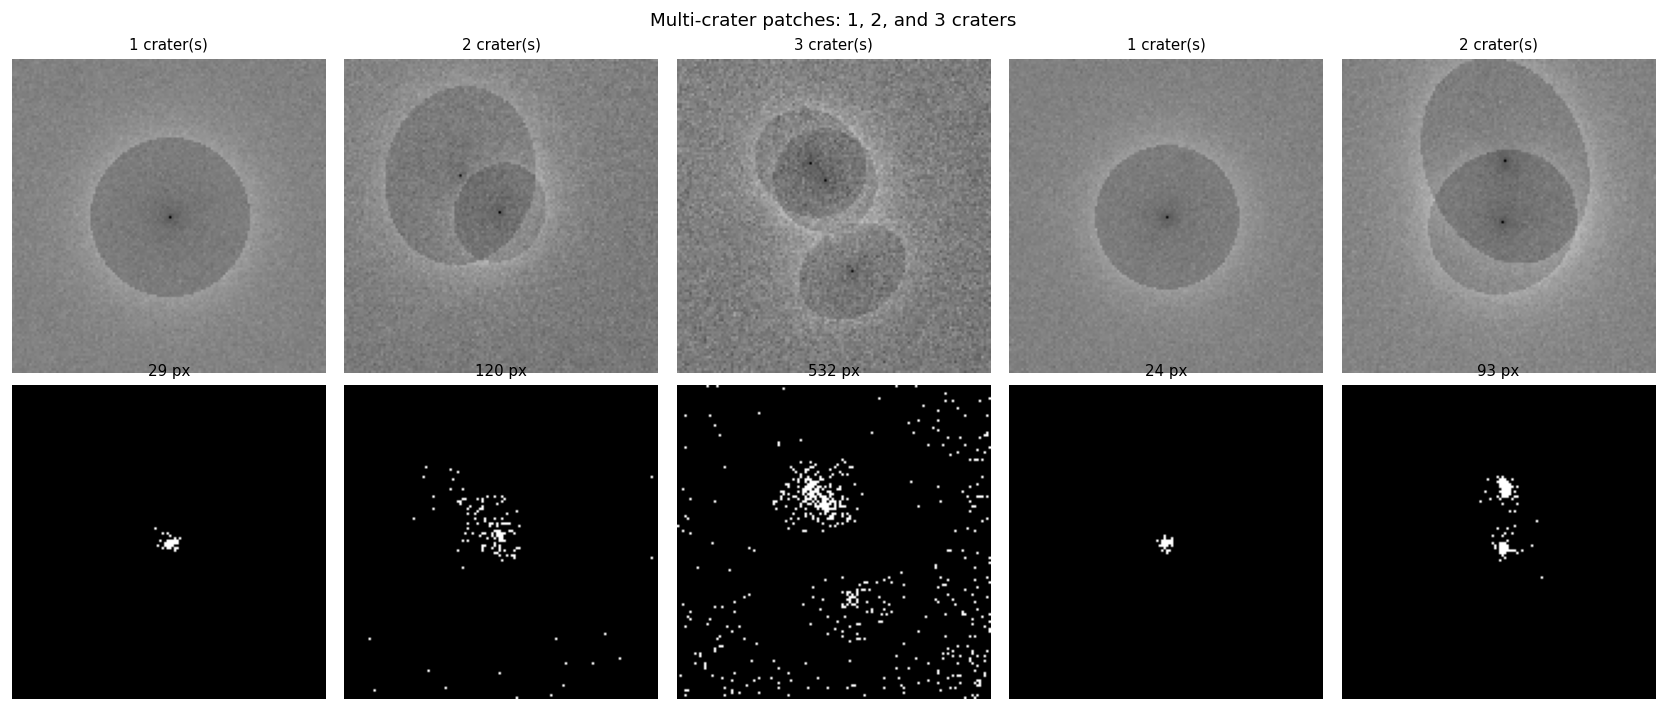

Saved: fig14_multi_crater.png


In [5]:
rng = np.random.default_rng(seed=42)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for col in range(5):
    n_craters = (col % 3) + 1
    if n_craters == 1:
        dem, mask = make_single_crater(r_s=rng.uniform(10, 25), noise_std=0.04, rng=rng)
    else:
        dem, mask = make_multi_crater_patch(n_craters=n_craters, noise_std=0.04, rng=rng)

    axes[0, col].imshow(dem, cmap='gray', vmin=-1, vmax=1)
    axes[0, col].set_title(f'{n_craters} crater(s)', fontsize=9)
    axes[0, col].axis('off')
    axes[1, col].imshow(mask, cmap='binary_r')
    axes[1, col].set_title(f'{mask.sum()} px', fontsize=9)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('DEM', fontsize=9)
axes[1, 0].set_ylabel('Mask', fontsize=9)
plt.suptitle('Multi-crater patches: 1, 2, and 3 craters', fontsize=11)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig14_multi_crater.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig14_multi_crater.png')

## 5. Generate the full synthetic dataset

In [6]:
import time

N_SYNTHETIC = 1500

t0 = time.time()
generate_synthetic_dataset(
    n_samples=N_SYNTHETIC,
    out_dir=str(SYNTH_DIR),
    size=128,
    seed=42,
    multi_crater_fraction=0.35,
)
elapsed = time.time() - t0

print(f'Generation time: {elapsed:.1f} s  ({elapsed/N_SYNTHETIC*1000:.1f} ms/patch)')
print('Files created:')
for f in sorted(SYNTH_DIR.iterdir()):
    print(f'  {f.name}: {f.stat().st_size/1e6:.1f} MB')

Generating 1500 synthetic patches (128x128)
  Single-crater: 975
  Multi-crater:  525
  1500/1500 - done
Saved to ../data/synthetic/
  synthetic_images.npy : (1500, 128, 128), 98.3 MB
  synthetic_masks.npy  : (1500, 128, 128)
  generation_log.csv   : 1500 rows
  Mask coverage stats  : mean=0.004, min=0, max=1
Generation time: 7.0 s  (4.7 ms/patch)
Files created:
  generation_log.csv: 0.1 MB
  synthetic_images.npy: 98.3 MB
  synthetic_masks.npy: 24.6 MB


## 6. Inspect the generated dataset

Images: (1500, 128, 128), dtype=float32
Masks : (1500, 128, 128),  dtype=uint8

Type distribution:
type
single    975
multi     525

Mask coverage: mean=0.004, std=0.006
Patches with empty mask: 0


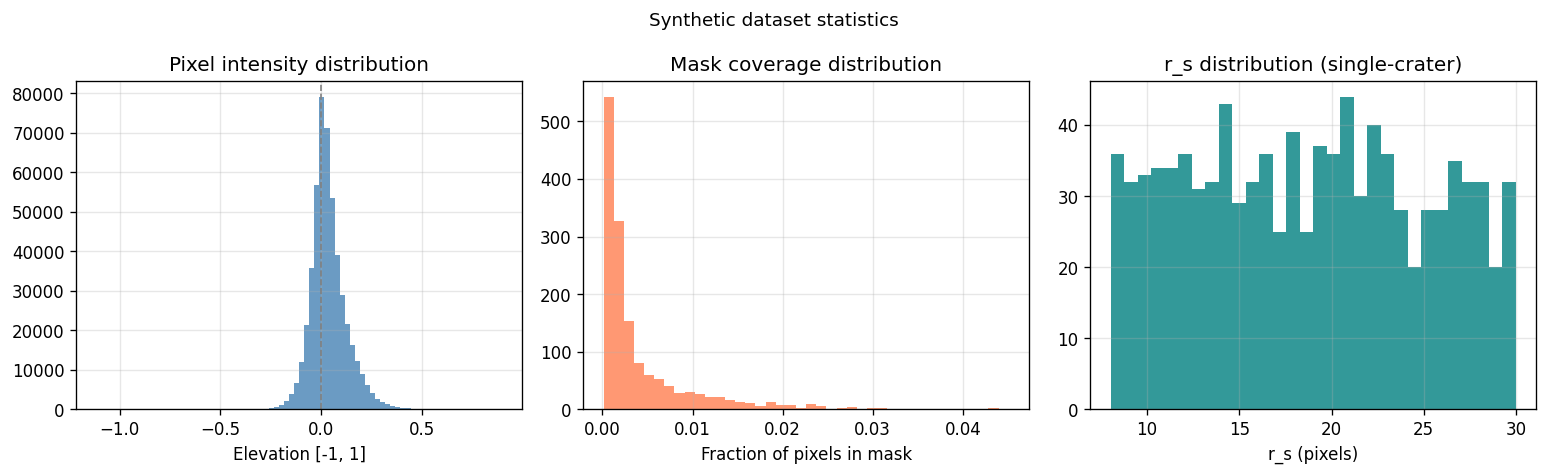

Saved: fig15_synthetic_stats.png


In [7]:
import pandas as pd

synth_images = np.load(SYNTH_DIR / 'synthetic_images.npy')
synth_masks  = np.load(SYNTH_DIR / 'synthetic_masks.npy')
gen_log      = pd.read_csv(SYNTH_DIR / 'generation_log.csv')

print(f'Images: {synth_images.shape}, dtype={synth_images.dtype}')
print(f'Masks : {synth_masks.shape},  dtype={synth_masks.dtype}')
print()
print('Type distribution:')
print(gen_log['type'].value_counts().to_string())

coverages = synth_masks.mean(axis=(1, 2))
print(f'\nMask coverage: mean={coverages.mean():.3f}, std={coverages.std():.3f}')
print(f'Patches with empty mask: {(coverages == 0).sum()}')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(synth_images.ravel()[::50], bins=80, color='steelblue', alpha=0.8)
axes[0].set_title('Pixel intensity distribution')
axes[0].set_xlabel('Elevation [-1, 1]')
axes[0].axvline(0, color='gray', ls='--', lw=1)
axes[1].hist(coverages, bins=40, color='coral', alpha=0.8)
axes[1].set_title('Mask coverage distribution')
axes[1].set_xlabel('Fraction of pixels in mask')
single_rs = gen_log[gen_log['type']=='single']['r_s'].values
axes[2].hist(single_rs, bins=30, color='teal', alpha=0.8)
axes[2].set_title('r_s distribution (single-crater)')
axes[2].set_xlabel('r_s (pixels)')
plt.suptitle('Synthetic dataset statistics', fontsize=11)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig15_synthetic_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig15_synthetic_stats.png')

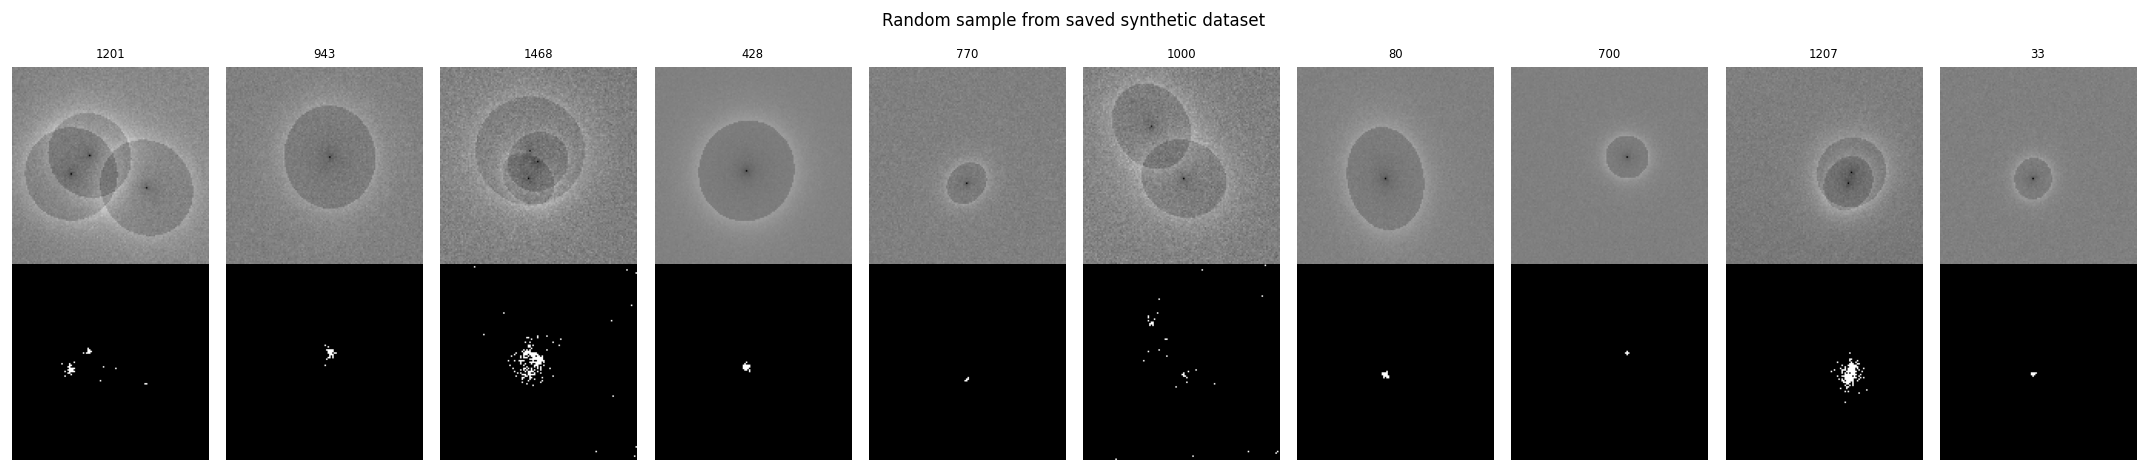

Saved: fig16_synthetic_sample.png


In [8]:
rng = np.random.default_rng(seed=5)
sample_idx = rng.choice(N_SYNTHETIC, size=10, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for col, idx in enumerate(sample_idx):
    axes[0, col].imshow(synth_images[idx], cmap='gray', vmin=-1, vmax=1)
    axes[0, col].axis('off')
    axes[0, col].set_title(f'{idx}', fontsize=7)
    axes[1, col].imshow(synth_masks[idx], cmap='binary_r')
    axes[1, col].axis('off')
axes[0, 0].set_ylabel('DEM', fontsize=9)
axes[1, 0].set_ylabel('Mask', fontsize=9)
plt.suptitle('Random sample from saved synthetic dataset', fontsize=10)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig16_synthetic_sample.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig16_synthetic_sample.png')

## 7. Run real DEM preprocessing pipeline

In [9]:
all_stats = []
for split in ['train', 'dev', 'test']:
    try:
        stats = process_split(split, data_dir=DATA_DIR, out_dir=PROC_DIR)
        all_stats.append(stats)
    except FileNotFoundError as e:
        print(f'Skipping {split}: {e}')

print()
print('Files in data/processed/:')
for f in sorted(PROC_DIR.iterdir()):
    print(f'  {f.name}: {f.stat().st_size/1e6:.1f} MB')


Processing split: train
----------------------------------------


AttributeError: 'Dataset' object has no attribute 'keys'

## 8. Verify PyTorch DataLoaders

In [ ]:
import torch
from torch.utils.data import DataLoader

# Synthetic dataset (always available)
synth_ds     = SyntheticCraterDataset(n_samples=1500, seed=42, augment=True)
synth_loader = DataLoader(synth_ds, batch_size=8, shuffle=True, num_workers=0)
imgs_s, masks_s = next(iter(synth_loader))

print('Synthetic batch:')
print(f'  images: {tuple(imgs_s.shape)}, dtype={imgs_s.dtype}')
print(f'  masks : {tuple(masks_s.shape)}, dtype={masks_s.dtype}')

# Real dataset (only if processed files exist)
real_img_path  = PROC_DIR / 'train_images.npy'
real_mask_path = PROC_DIR / 'train_masks.npy'

if real_img_path.exists() and real_mask_path.exists():
    real_ds     = RealCraterDataset(real_img_path, real_mask_path, augment=True)
    real_loader = DataLoader(real_ds, batch_size=8, shuffle=True, num_workers=0)
    imgs_r, masks_r = next(iter(real_loader))
    print()
    print('Real batch:')
    print(f'  images: {tuple(imgs_r.shape)}')
    print(f'  Real dataset length: {len(real_ds)}')

    combined_ds     = CombinedDataset(synth_ds, real_ds)
    combined_loader = DataLoader(combined_ds, batch_size=8, shuffle=True, num_workers=0)
    imgs_c, _ = next(iter(combined_loader))
    print(f'  Combined dataset length: {len(combined_ds)}')
else:
    print()
    print('Real processed data not found. Using synthetic only.')

assert imgs_s.shape == (8, 1, 128, 128)
assert imgs_s.dtype == torch.float32
assert masks_s.dtype == torch.float32
print()
print('All assertions passed.')

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for col in range(8):
    axes[0, col].imshow(imgs_s[col, 0].numpy(), cmap='gray', vmin=-1, vmax=1)
    axes[0, col].axis('off')
    axes[1, col].imshow(masks_s[col, 0].numpy(), cmap='binary_r')
    axes[1, col].axis('off')
axes[0, 0].set_ylabel('DEM', fontsize=9)
axes[1, 0].set_ylabel('Mask', fontsize=9)
plt.suptitle('One batch from SyntheticCraterDataset (augmented)', fontsize=10)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig17_dataloader_batch.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig17_dataloader_batch.png')

## 9. Class balance and pos_weight

In [ ]:
coverages  = synth_masks.mean(axis=(1, 2))
mean_cov   = coverages.mean()
pos_weight = (1.0 - mean_cov) / (mean_cov + 1e-6)

print('Class balance (synthetic dataset):')
print(f'  Mean crater pixel fraction : {mean_cov:.4f}')
print(f'  Mean background fraction   : {1 - mean_cov:.4f}')
print(f'  Imbalance ratio            : {(1-mean_cov)/mean_cov:.1f}:1')
print(f'  Recommended pos_weight     : {pos_weight:.2f}')
print()
print('pos_weight will be passed to torch.nn.BCEWithLogitsLoss.')
print('It upweights crater pixels to prevent the model predicting all-background.')

np.save(DATA_DIR / 'pos_weight.npy', np.array([pos_weight]))
print(f'Saved to data/pos_weight.npy')

## 10. Day 3 summary

In [ ]:
print('=== Day 3 Summary ===')
print()
print('Files created:')
print('  src/synthetic.py     - production NFW generator + PyTorch Dataset classes')
print('  src/preprocessing.py - real DEM loading, downsampling, normalisation, filtering')
print()
print('Data generated:')
print(f'  data/synthetic/synthetic_images.npy : {N_SYNTHETIC} patches, {synth_images.nbytes/1e6:.0f} MB')
print(f'  data/synthetic/synthetic_masks.npy  : paired binary masks')
print(f'  data/synthetic/generation_log.csv   : per-sample parameters')
print(f'  data/pos_weight.npy                 : {pos_weight:.2f}')
print()
figs = ['fig13_generator_ablation', 'fig14_multi_crater', 'fig15_synthetic_stats',
        'fig16_synthetic_sample', 'fig17_dataloader_batch']
print('Figures generated:')
for name in figs:
    status = 'OK' if (DOCS_DIR / f'{name}.png').exists() else 'MISSING'
    print(f'  {status}: docs/{name}.png')
print()
print('Decisions for Day 4:')
print(f'  pos_weight                 : {pos_weight:.2f}')
print('  Batch size                 : 8 (CPU memory constraint)')
print('  Pretraining epochs         : 30 on synthetic')
print('  Fine-tuning epochs         : 50 on real')
print('  num_workers in DataLoader  : 0 (WSL compatibility)')